In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the Mauna Loa CO2 dataset

file_path = "mauna_loa_co2_monthly_mean_data.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
display(df.head())

Dataset loaded successfully!


,# --------------------------------------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,# USE OF NOAA GML DATA,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,# These data are made freely available to the ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,# community in the belief that their wide diss...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,# greater understanding and new scientific ins...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Plot the complete CO2 time series

plt.figure(figsize=(14, 6))

plt.plot(
    df["decimal date"],
    df["average"],
    linewidth=1.5
)

plt.title("Monthly Atmospheric CO2 Concentration")
plt.xlabel("Year")
plt.ylabel("CO2 Concentration (ppm)")
plt.grid(True)

plt.show()

KeyError: 'decimal date'

<Figure size 1400x600 with 0 Axes>

In [4]:
print(df.columns.tolist())

['# --------------------------------------------------------------------', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7']


In [5]:
# Reload the dataset while ignoring comment lines

file_path = "mauna_loa_co2_monthly_mean_data.csv"

df = pd.read_csv(file_path, comment="#")

print("Dataset loaded successfully!")
print("Columns:")
print(df.columns.tolist())

display(df.head())

Dataset loaded successfully!
Columns:
['year', 'month', 'decimal date', 'average', 'deseasonalized', 'ndays', 'sdev', 'unc']


,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99


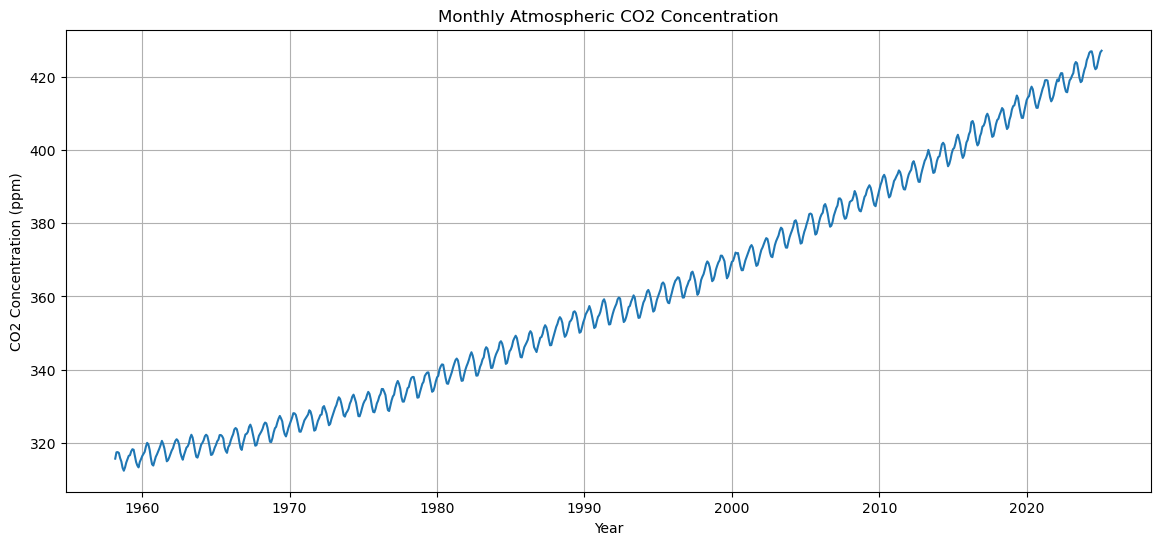

In [6]:
# Plot the complete CO2 time series

plt.figure(figsize=(14, 6))

plt.plot(
    df["year"] + (df["month"] - 1) / 12,
    df["average"],
    linewidth=1.5
)

plt.title("Monthly Atmospheric CO2 Concentration")
plt.xlabel("Year")
plt.ylabel("CO2 Concentration (ppm)")
plt.grid(True)

plt.show()

In [7]:
# Calculate 12-month moving average

df["moving_average_12"] = df["average"].rolling(window=12).mean()

print("12-month moving average calculated successfully!")

display(df[["year", "month", "average", "moving_average_12"]].head(15))


12-month moving average calculated successfully!


,year,month,average,moving_average_12
0,1958,3,315.71,NaN
1,1958,4,317.45,NaN
2,1958,5,317.51,NaN
3,1958,6,317.27,NaN
4,1958,7,315.87,NaN
5,1958,8,314.93,NaN
6,1958,9,313.21,NaN
7,1958,10,312.42,NaN
8,1958,11,313.33,NaN
9,1958,12,314.67,NaN


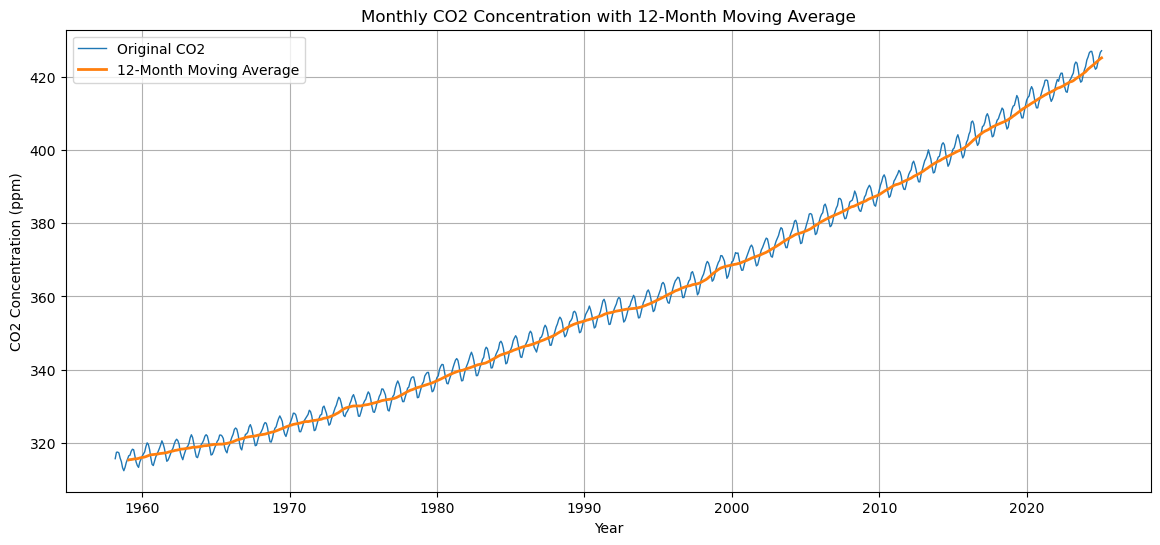

In [8]:
# Plot original CO2 series and 12-month moving average

plt.figure(figsize=(14, 6))

plt.plot(
    df["year"] + (df["month"] - 1) / 12,
    df["average"],
    label="Original CO2",
    linewidth=1
)

plt.plot(
    df["year"] + (df["month"] - 1) / 12,
    df["moving_average_12"],
    label="12-Month Moving Average",
    linewidth=2
)

plt.title("Monthly CO2 Concentration with 12-Month Moving Average")
plt.xlabel("Year")
plt.ylabel("CO2 Concentration (ppm)")
plt.legend()
plt.grid(True)

plt.show()

In [9]:
# Perform seasonal decomposition

decomposition = seasonal_decompose(
    df["average"],
    model="additive",
    period=12
)

print("Seasonal decomposition completed successfully!")

Seasonal decomposition completed successfully!


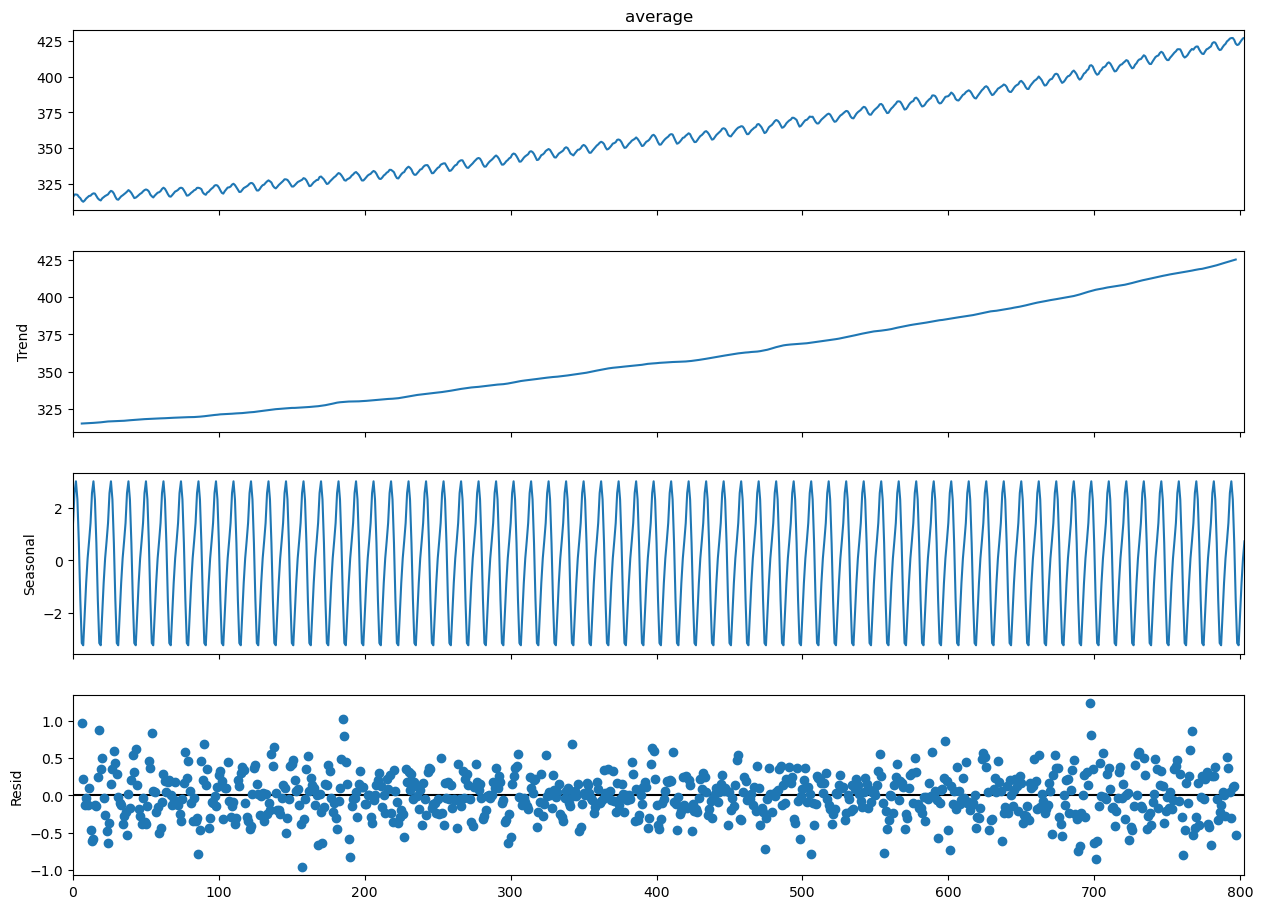

In [10]:
# Plot the decomposition components

fig = decomposition.plot()

fig.set_size_inches(14, 10)

plt.show()

In [11]:
# Extract the four decomposition components

observed = decomposition.observed
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

print("Trend component:")
display(trend.head(15))

print("Seasonal component:")
display(seasonal.head(15))

print("Residual component:")
display(residual.head(15))

Trend component:


0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
5            NaN
6     315.409167
7     315.459583
8     315.503333
9     315.572500
10    315.637083
11    315.659583
12    315.680417
13    315.744583
14    315.844167
Name: trend, dtype: float64

Seasonal component:


0     1.433496
1     2.585226
2     3.031792
3     2.335750
4     0.661331
5    -1.514067
6    -3.170601
7    -3.255658
8    -2.049932
9    -0.863966
10    0.076969
11    0.729658
12    1.433496
13    2.585226
14    3.031792
Name: seasonal, dtype: float64

Residual component:


0          NaN
1          NaN
2          NaN
3          NaN
4          NaN
5          NaN
6     0.971434
7     0.216074
8    -0.123402
9    -0.038534
10   -0.134052
11    0.100759
12   -0.463913
13   -0.609810
14   -0.585959
Name: resid, dtype: float64

In [12]:
# Calculate average seasonal effect for each month

df["month_name"] = pd.to_datetime(
    df["month"], format="%m"
).dt.month_name()

monthly_seasonal_effect = (
    df.groupby("month")["seasonal"]
    .mean()
)

print("Average seasonal effect for each month:")
display(monthly_seasonal_effect)

KeyError: 'Column not found: seasonal'

In [13]:
# Calculate average seasonal effect for each month

monthly_seasonal_effect = seasonal.groupby(df["month"]).mean()

print("Average seasonal effect for each month:")
display(monthly_seasonal_effect)

Average seasonal effect for each month:


month
1     0.076969
2     0.729658
3     1.433496
4     2.585226
5     3.031792
6     2.335750
7     0.661331
8    -1.514067
9    -3.170601
10   -3.255658
11   -2.049932
12   -0.863966
Name: seasonal, dtype: float64

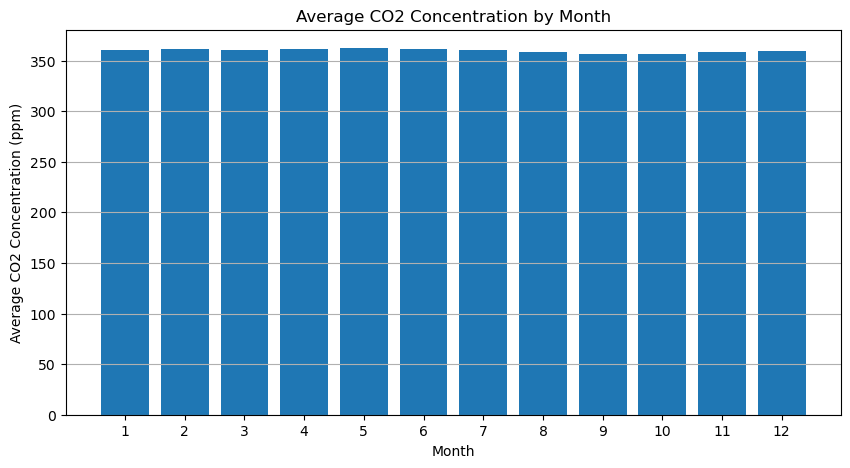

In [15]:
# Bar plot of average CO2 concentration by month

monthly_average_co2 = df.groupby("month")["average"].mean()

plt.figure(figsize=(10, 5))

plt.bar(
    monthly_average_co2.index,
    monthly_average_co2.values
)

plt.title("Average CO2 Concentration by Month")
plt.xlabel("Month")
plt.ylabel("Average CO2 Concentration (ppm)")
plt.xticks(range(1, 13))
plt.grid(axis="y")

plt.show()